In [35]:
import time

import mne
import numpy as np
import os
import sys

sys.path.insert(1, "../../")
sys.path.insert(1, "../")  # to read the models
sys.path.insert(1, "bin/")  # to be able to import the function from the bin folder

from preprocess import Epoching, preprocess
from read_data import *
from utils import *
import time

In [7]:

init_path = "../../../../Dataset/Big_dataset"
# Read the data
participant_dir, files_dir = read_bigdataset_data(init_path)
#
files_dir = [files_dir[0]] # take only the first file for debuging
participant_dir= [participant_dir[0][10:11]]# take only the first 4 participant for debuging
session = [sub for sess in participant_dir for sub in sess]  #get the list of all participant

dic_data = collect_data(files_dir, participant_dir, init_path)
steps_epoching = {"tmin": 0.5,
                  "tmax": 4.5,
                  "overlap": 1,
                  "lenght": 2,
                  "n_events_per_trial": 40,
                  "one_hot": False}

n_classes = 2
n_chans = 27
sfreq = dic_data["A19_1"].info["sfreq"]
input_window_samples = int(sfreq * steps_epoching["lenght"])


you have succesfuly acces to the directory :  ../../../../Dataset/Big_dataset
['DATA A', 'DATA B', 'DATA C']
[['A1', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A2', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A3', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A4', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A5', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A6', 'A60', 'A7', 'A8', 'A9'], ['B61', 'B62', 'B63', 'B64', 'B65', 'B66', 'B67', 'B68', 'B69', 'B70', 'B71', 'B72', 'B73', 'B74', 'B75', 'B76', 'B77', 'B78', 'B79', 'B80', 'B81'], ['C82', 'C83', 'C84', 'C85', 'C86', 'C87']]


In [23]:
raw_signal = dic_data["A19_1"]
# raw_signal.drop_channels(['EOG1', 'EOG2', 'EOG3', 'EMGg', 'EMGd'])  # Supprimer les canaux non EEG
raw_signal.load_data()
raw_signal.filter(1, 40, fir_design='firwin', skip_by_annotation='edge')

eeg_data = raw_signal.get_data(picks='eeg')  # Sélectionner uniquement les canaux EEG
montage = mne.channels.make_standard_montage("standard_1020")
ch_names = ['Fz', 'FCz', 'Cz', 'CPz', 'Pz', 'C1', 'C3', 'C5', 'C2', 'C4', 'C6', 'F4', 'FC2', 'FC4', 'FC6', 'CP2', 'CP4',
            'CP6', 'P4', 'F3', 'FC1', 'FC3', 'FC5', 'CP1', 'CP3', 'CP5', 'P3']
ch_pos = montage.get_positions()["ch_pos"]
ch_pos = np.array([ch_pos[ch_name][:2] for ch_name in ch_names])

raw_signal = raw_signal.set_montage(montage)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (3.303 s)


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


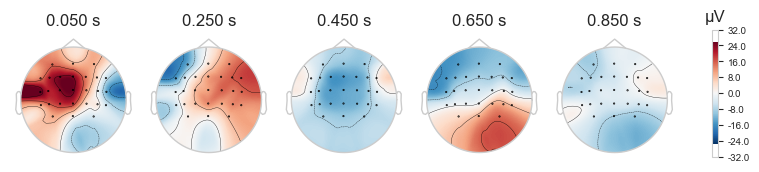

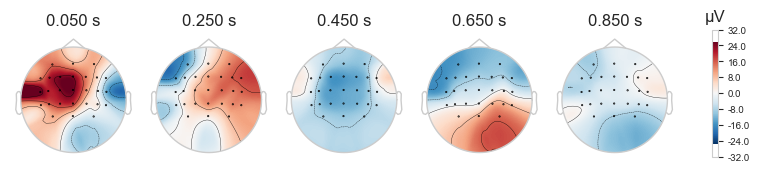

In [64]:
# Calculer les moyennes des données pour un topomap (par exemple, à un instant donné)
times =  np.arange(0.05, 1, 0.2)  # Temps en secondes pour le topomap
evoked = mne.EvokedArray(eeg_data, raw_signal.info, tmin=0)

# Tracer le topomap
evoked.plot_topomap(times)

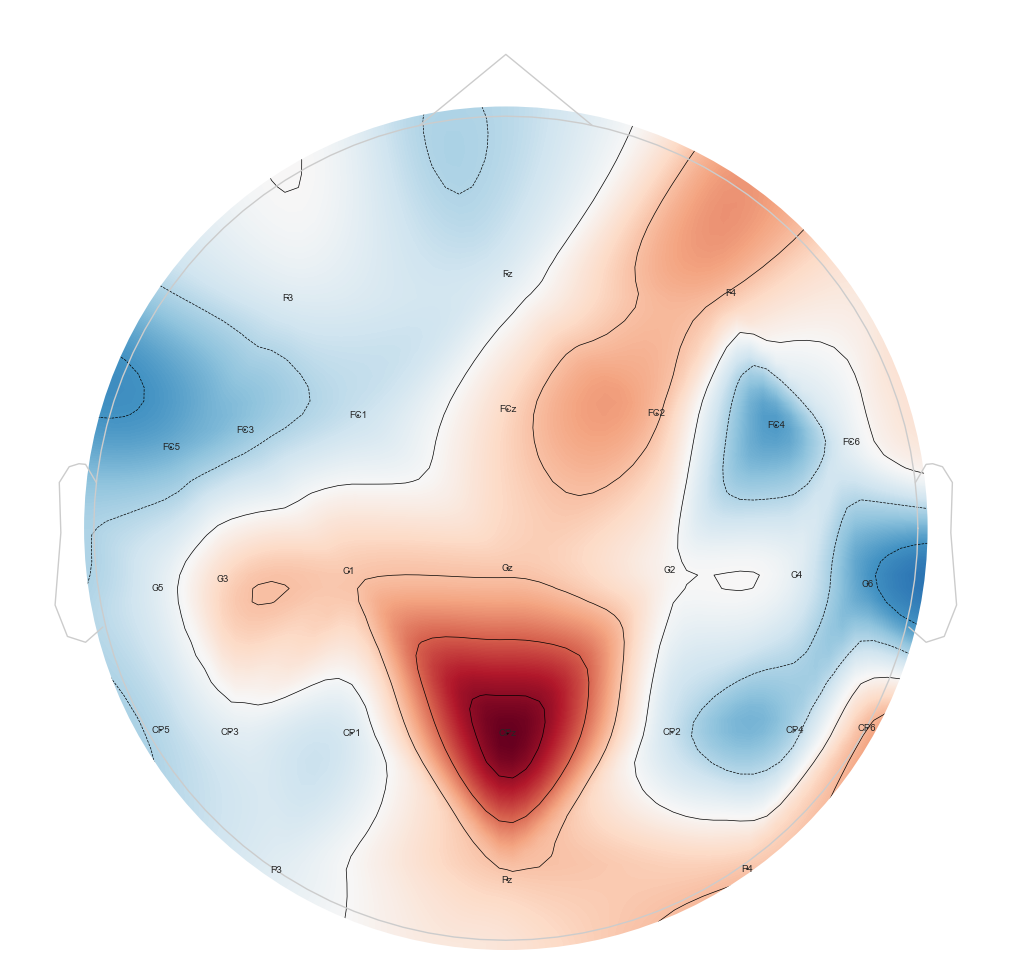

(<matplotlib.image.AxesImage at 0x16318710070>,
 <matplotlib.contour.QuadContourSet at 0x16318710430>)

In [28]:
mne.viz.plot_topomap(eeg_data.mean(axis=1), ch_pos, names=ch_names, size=10)

In [74]:
epoch= mne.Epochs(raw_signal, mne.events_from_annotations(raw_signal,{"769":0 ,"770":1})[0], tmin= -1 , tmax= 5 , baseline=(-1, 0))

epoch_data = epoch.get_data(picks='eeg')  # Sélectionner uniquement les canaux EEG

Used Annotations descriptions: ['769', '770']
Not setting metadata
40 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 40 events and 3073 original time points ...
0 bad epochs dropped


In [32]:
window_size = int(sfreq) 
window = np.ones(window_size) / window_size

# Appliquer la convolution pour calculer la moyenne glissante
smoothed_data = np.array([np.convolve(row, window, mode='valid') for row in eeg_data])

print(smoothed_data)

[[ 3.27503799e-07  3.33356630e-07  3.40693632e-07 ... -2.97834286e-05
  -2.98555428e-05 -2.99294381e-05]
 [ 2.24453928e-06  2.24492928e-06  2.24171753e-06 ...  4.84663784e-05
   4.85727244e-05  4.86792564e-05]
 [ 2.61540157e-06  2.61219625e-06  2.60369897e-06 ...  6.31612928e-05
   6.32933181e-05  6.34266367e-05]
 ...
 [ 1.07374288e-06  1.08606881e-06  1.09204721e-06 ... -2.50785784e-05
  -2.51410926e-05 -2.52036651e-05]
 [ 3.93280413e-07  4.03167301e-07  4.08259084e-07 ... -6.52635694e-05
  -6.54075793e-05 -6.55530838e-05]
 [ 3.41723633e-07  3.54917546e-07  3.64846975e-07 ... -2.87303824e-05
  -2.87925343e-05 -2.88540753e-05]]


In [42]:
3072/512


6.0

In [ ]:
for i in range(smoothed_data.shape[1]//100):

    mne.viz.plot_topomap(smoothed_data[:,i*100], ch_pos, names=ch_names, size=10 ,show=False)



In [55]:
# Reshape pour regrouper les 512 échantillons
epoch_data = epoch_data[:, :, :3072]  # Truncate to make it divisible by 512
data_reshaped = epoch_data.reshape(epoch_data.shape[0], epoch_data.shape[1], -1, int(512/4))

# Calculer la moyenne sur la dernière dimension (512 échantillons)
data_reduced = data_reshaped.mean(axis=-1)

In [59]:
data_reduced.shape
data_reduced = data_reduced**2

In [65]:
# for i in range(data_reduced.shape[2]):
#     mne.viz.plot_topomap(data_reduced[3,:,i], ch_pos, names=ch_names, size=10 ,show=True)

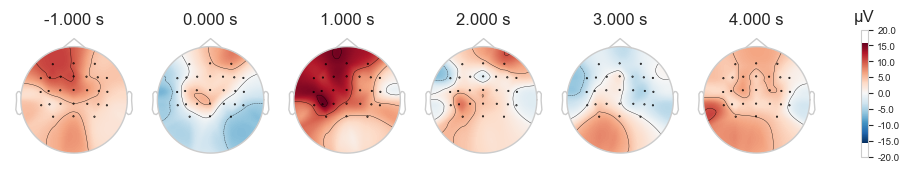

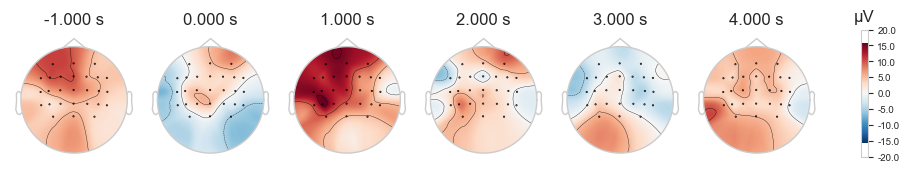

In [76]:
# Calculer les moyennes des données pour un topomap (par exemple, à un instant donné)
times =  np.arange(-1, 5,1)  # Temps en secondes pour le topomap
evoked = mne.EvokedArray(epoch_data[0], raw_signal.info, tmin=-1)

# Tracer le topomap
evoked.plot_topomap(times)